In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Carga de datos del archivo agrupacion_csv de la clave F


In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/AsaelP25/Parcial4_Humberto_Parada_2510772022/refs/heads/main/Archivos/clave_F_agrupacion.csv')
df.head()

,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,F-R0218,47,1028,5.48,63.75,3.04,5,13
1,F-R0008,35,733,1.41,25.26,5.60,3,3
2,F-R0082,36,985,9.98,98.95,7.11,3,27
3,F-R0009,30,473,1.61,5.00,5.76,12,1
4,F-R0244,39,978,2.57,27.35,3.31,4,10


In [4]:
df.shape

(250, 8)

In [6]:
df.columns

Index(['registro_id', 'edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio',
       'satisfaccion', 'reclamos', 'antiguedad_meses'],
      dtype='object')

El dataset de agrupación contiene información de clientes o registros con variables como edad, ingresos, frecuencia de uso, gasto promedio, satisfacción, reclamos y antigüedad en meses.

Verificar valores nulos, duplicados y tipos de datos.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   registro_id       250 non-null    object 
 1   edad              250 non-null    int64  
 2   ingresos          250 non-null    int64  
 3   frecuencia_uso    250 non-null    float64
 4   gasto_promedio    250 non-null    float64
 5   satisfaccion      249 non-null    float64
 6   reclamos          250 non-null    int64  
 7   antiguedad_meses  250 non-null    int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 15.8+ KB


In [7]:
df.isnull().sum()

,0
registro_id,0
edad,0
ingresos,0
frecuencia_uso,0
gasto_promedio,0
satisfaccion,1
reclamos,0
antiguedad_meses,0


In [8]:
df.duplicated().sum()

np.int64(0)

Limpiar datos

In [10]:
df["satisfaccion"] = df["satisfaccion"].fillna(
    df["satisfaccion"].median()
)

In [11]:
df.isnull().sum()

,0
registro_id,0
edad,0
ingresos,0
frecuencia_uso,0
gasto_promedio,0
satisfaccion,0
reclamos,0
antiguedad_meses,0


In [12]:
df.duplicated().sum()

np.int64(0)

Durante la revisión inicial del dataset se identificó un valor nulo en la columna satisfaccion y no se encontraron registros duplicados.

El valor nulo fue reemplazado utilizando la mediana de la columna. Después de la limpieza, el dataset quedó sin valores nulos ni duplicados.

Seleccionar variables para clustering

In [14]:
variables_clustering = df[
    [
        "edad",
        "ingresos",
        "frecuencia_uso",
        "gasto_promedio",
        "satisfaccion",
        "reclamos",
        "antiguedad_meses"
    ]
]

variables_clustering.head()

,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,47,1028,5.48,63.75,3.04,5,13
1,35,733,1.41,25.26,5.60,3,3
2,36,985,9.98,98.95,7.11,3,27
3,30,473,1.61,5.00,5.76,12,1
4,39,978,2.57,27.35,3.31,4,10


Para el análisis de clustering se seleccionaron variables numéricas relacionadas con el comportamiento y perfil del cliente.

Normalizar los datos

In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
scaler = StandardScaler()

datos_escalados = scaler.fit_transform(variables_clustering)

In [17]:
datos_escalados_df = pd.DataFrame(
    datos_escalados,
    columns=variables_clustering.columns
)

datos_escalados_df.head()

,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,0.775847,-0.083904,0.014450,-0.425503,-1.973425,1.307568,-0.408574
1,-0.424535,-0.772445,-1.320937,-1.206722,-0.655695,0.298642,-1.174841
2,-0.324503,-0.184268,1.490921,0.288939,0.121561,0.298642,0.664200
3,-0.924694,-1.379295,-1.255316,-1.617932,-0.573336,4.838810,-1.328094
4,-0.024408,-0.200606,-0.940335,-1.164302,-1.834446,0.803105,-0.638454


Se normalizaron las variables utilizando StandardScaler. Este proceso transforma los datos para que tengan una escala comparable.

La normalización es necesaria porque K-Means calcula distancias entre registros. Si no se normalizan los datos, variables con valores más grandes, como ingresos, podrían tener mayor influencia que otras variables como satisfacción o reclamos.

Aplicar método del codo

In [18]:
from sklearn.cluster import KMeans

In [19]:
inercias = []

for k in range(1, 9):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(datos_escalados)
    inercias.append(modelo.inertia_)

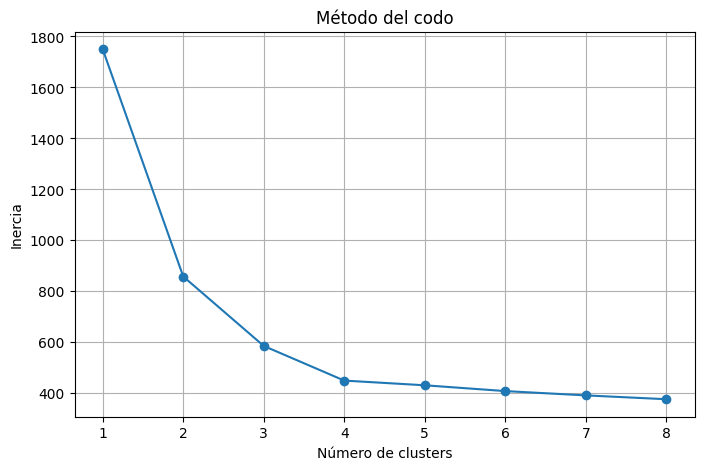

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 9), inercias, marker="o")
plt.title("Método del codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

El método del codo permite seleccionar un número adecuado de clusters observando el punto donde la reducción de la inercia comienza a disminuir de forma menos pronunciada.

En este análisis se seleccionaron 3 clusters, ya que representan una segmentación clara y permiten interpretar grupos diferenciados de clientes.

In [22]:
modelo_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["cluster"] = modelo_kmeans.fit_predict(datos_escalados)

In [24]:
df.head()

,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses,cluster
0,F-R0218,47,1028,5.48,63.75,3.04,5,13,0
1,F-R0008,35,733,1.41,25.26,5.60,3,3,0
2,F-R0082,36,985,9.98,98.95,7.11,3,27,2
3,F-R0009,30,473,1.61,5.00,5.76,12,1,0
4,F-R0244,39,978,2.57,27.35,3.31,4,10,0


In [25]:
df["cluster"].value_counts().sort_index()

,count
cluster,
0,120
1,62
2,68


Analizar promedio de cada cluster

In [26]:
resumen_clusters = df.groupby("cluster")[
    [
        "edad",
        "ingresos",
        "frecuencia_uso",
        "gasto_promedio",
        "satisfaccion",
        "reclamos",
        "antiguedad_meses"
    ]
].mean().round(2)

resumen_clusters

,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
cluster,,,,,,,
0,34.84,750.19,2.96,46.76,5.19,3.98,9.73
1,51.23,1655.63,9.09,157.12,8.71,0.68,35.34
2,36.09,1078.16,6.48,85.67,8.18,1.22,18.00


Visualizar los clusters

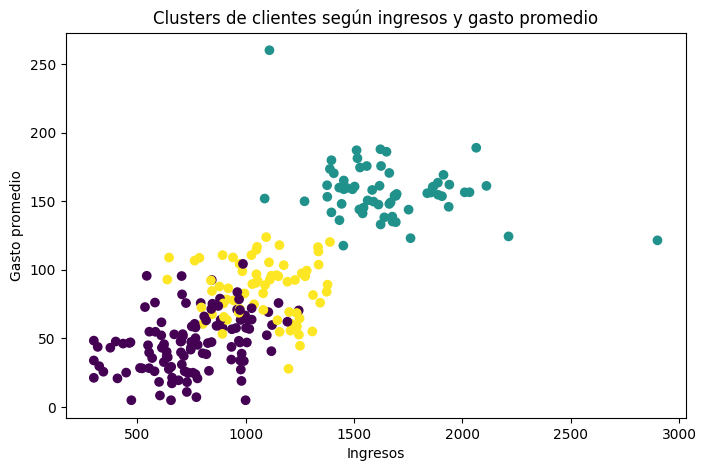

In [28]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["ingresos"],
    df["gasto_promedio"],
    c=df["cluster"]
)

plt.title("Clusters de clientes según ingresos y gasto promedio")
plt.xlabel("Ingresos")
plt.ylabel("Gasto promedio")
plt.show()

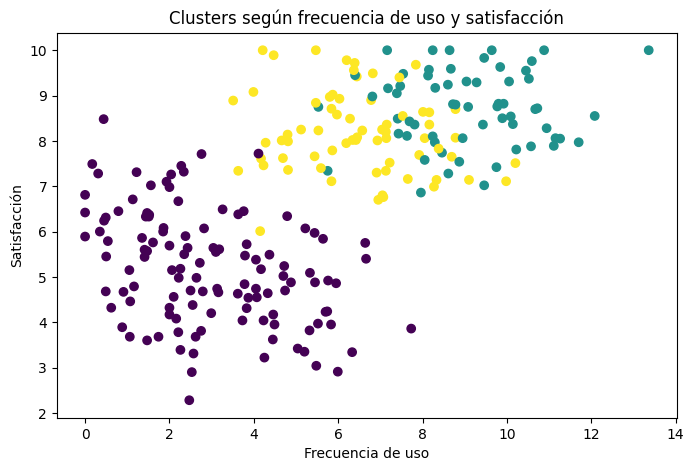

In [30]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["frecuencia_uso"],
    df["satisfaccion"],
    c=df["cluster"]
)

plt.title("Clusters según frecuencia de uso y satisfacción")
plt.xlabel("Frecuencia de uso")
plt.ylabel("Satisfacción")
plt.show()

Los gráficos permiten observar visualmente cómo se distribuyen los clientes según los clusters asignados. En este caso, se utilizaron variables como ingresos, gasto promedio, frecuencia de uso y satisfacción para representar las diferencias entre los grupos.

In [31]:
df.to_csv("dataset_final_con_clusters.csv", index=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')